In [73]:
import torch
import torch.nn as nn
import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [74]:
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)

In [75]:
data = pd.read_csv("train_dataset.csv")
data

,YearBuilt,Size(sqf),Floor,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,...,SubwayStation_Banwoldang,SubwayStation_Chil-sung-market,SubwayStation_Daegu,SubwayStation_Kyungbuk_uni_hospital,SubwayStation_Myung-duk,SubwayStation_Sin-nam,SubwayStation_no_subway_nearby,SalePrice,PriceCategoryNum,PriceCategory
0,2006.0,814.0,3.0,0.0,0.0,111.0,184.0,7.5,12.5,3.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,141592.0,1.0,average
1,1985.0,587.0,8.0,0.0,1.0,80.0,76.0,2.5,7.5,2.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,51327.0,0.0,cheap
2,1985.0,587.0,6.0,0.0,1.0,80.0,76.0,2.5,7.5,2.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,48672.0,0.0,cheap
3,2006.0,2056.0,8.0,0.0,0.0,249.0,536.0,2.5,2.5,5.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,380530.0,2.0,expensive
4,1992.0,644.0,2.0,0.0,1.0,142.0,79.0,7.5,17.5,4.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,78318.0,0.0,cheap
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4119,2007.0,1928.0,24.0,0.0,0.0,0.0,1270.0,2.5,2.5,14.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,570796.0,2.0,expensive
4120,2015.0,644.0,22.0,0.0,0.0,102.0,400.0,2.5,7.5,5.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,307079.0,1.0,average
4121,2007.0,868.0,20.0,0.0,0.0,0.0,1270.0,2.5,2.5,14.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,357522.0,2.0,expensive
4122,1978.0,1327.0,1.0,0.0,1.0,87.0,0.0,2.5,2.5,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,312389.0,1.0,average


In [76]:
X = data.loc[:, :"SubwayStation_no_subway_nearby"]
y = data[["PriceCategoryNum", "SalePrice"]]

In [77]:
features_scaler = joblib.load("features_scaler.pkl")
sale_price_scaler = joblib.load("sale_price_scaler.pkl")

In [78]:
X = pd.DataFrame(features_scaler.transform(X), columns=X.columns)
y.loc[:, "SalePrice"] = sale_price_scaler.transform(y[["SalePrice"]])


/var/folders/rh/8hh2vd4j4xzcvyl1kj3kzf600000gn/T/ipykernel_17429/1147299762.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[[-0.75800464]
 [-1.60705699]
 [-1.6320305 ]
 ...
 [ 1.27308021]
 [ 0.84854933]
 [ 1.61436605]]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  y.loc[:, "SalePrice"] = sale_price_scaler.transform(y[["SalePrice"]])


In [79]:
X.describe()

,YearBuilt,Size(sqf),Floor,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,...,HallwayType_mixed,HallwayType_terraced,SubwayStation_Bangoge,SubwayStation_Banwoldang,SubwayStation_Chil-sung-market,SubwayStation_Daegu,SubwayStation_Kyungbuk_uni_hospital,SubwayStation_Myung-duk,SubwayStation_Sin-nam,SubwayStation_no_subway_nearby
count,4.124000e+03,4.124000e+03,4.124000e+03,4.124000e+03,4.124000e+03,4.124000e+03,4.124000e+03,4.124000e+03,4.124000e+03,4.124000e+03,...,4124.000000,4.124000e+03,4124.000000,4.124000e+03,4.124000e+03,4.124000e+03,4.124000e+03,4.124000e+03,4.124000e+03,4124.000000
mean,1.998617e-15,3.445891e-17,2.067535e-17,-6.891782e-18,4.479658e-17,-5.513426e-17,1.378356e-17,-2.067535e-17,1.378356e-17,1.378356e-17,...,0.000000,-1.378356e-16,0.000000,-2.067535e-17,-3.445891e-17,7.064077e-17,-9.648495e-17,1.206062e-17,-7.236371e-17,0.000000
std,1.000121e+00,1.000121e+00,1.000121e+00,1.000121e+00,1.000121e+00,1.000121e+00,1.000121e+00,1.000121e+00,1.000121e+00,1.000121e+00,...,1.000121,1.000121e+00,1.000121,1.000121e+00,1.000121e+00,1.000121e+00,1.000121e+00,1.000121e+00,1.000121e+00,1.000121
min,-2.849809e+00,-2.145526e+00,-1.450405e+00,-2.173295e-01,-2.567265e-01,-8.949043e-01,-1.403614e+00,-5.445820e-01,-7.714661e-01,-1.648108e+00,...,-0.638364,-1.231328e+00,-0.376497,-3.844312e-01,-1.450683e-01,-1.235452e-01,-6.124745e-01,-5.900449e-01,-3.577831e-01,-0.267816
25%,-1.138413e+00,-8.217354e-01,-7.908101e-01,-2.173295e-01,-2.567265e-01,-8.438435e-01,-9.527778e-01,-5.445820e-01,-7.714661e-01,-4.074769e-01,...,-0.638364,-1.231328e+00,-0.376497,-3.844312e-01,-1.450683e-01,-1.235452e-01,-6.124745e-01,-5.900449e-01,-3.577831e-01,-0.267816
50%,3.447967e-01,-1.299312e-01,-1.312152e-01,-2.173295e-01,-2.567265e-01,-4.307159e-01,-9.030853e-02,-5.445820e-01,-1.295117e-01,-9.731915e-02,...,-0.638364,8.121314e-01,-0.376497,-3.844312e-01,-1.450683e-01,-1.235452e-01,-6.124745e-01,-5.900449e-01,-3.577831e-01,-0.267816
75%,4.588898e-01,5.202608e-01,6.602986e-01,-2.173295e-01,-2.567265e-01,2.609247e-01,5.516431e-01,-5.445820e-01,5.124427e-01,5.229964e-01,...,1.566504,8.121314e-01,-0.376497,-3.844312e-01,-1.450683e-01,-1.235452e-01,1.632721e+00,1.694786e+00,-3.577831e-01,-0.267816
max,1.371634e+00,3.581365e+00,4.090192e+00,4.601309e+00,3.895196e+00,2.414759e+00,1.833096e+00,3.885115e+00,3.401238e+00,2.383943e+00,...,1.566504,8.121314e-01,2.656066,2.601246e+00,6.893305e+00,8.094203e+00,1.632721e+00,1.694786e+00,2.794989e+00,3.733903


In [80]:
y.describe()

,PriceCategoryNum,SalePrice
count,4124.000000,4.124000e+03
mean,1.001940,5.513426e-17
std,0.523979,1.000121e+00
min,0.000000,-1.769380e+00
25%,1.000000,-7.282810e-01
50%,1.000000,-1.184194e-01
75%,1.000000,6.527213e-01
max,2.000000,3.420689e+00


In [81]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_SEED
)

X_train.shape, y_train.shape

((3505, 25), (3505, 2))

In [82]:
def create_dataset(X: pd.DataFrame, y: pd.DataFrame) -> torch.utils.data.Dataset:
    X_tensor = torch.Tensor(X.to_numpy())
    y_tensor = torch.Tensor(y.to_numpy()).squeeze()
    return torch.utils.data.TensorDataset(X_tensor, y_tensor)


train_dataset = create_dataset(X_train, y_train["PriceCategoryNum"])
val_dataset = create_dataset(X_val, y_val["PriceCategoryNum"])


In [83]:
# from sklearn.utils.class_weight import compute_class_weight

# y_train_numpy = np.squeeze(y_train.to_numpy())
# y_train_numpy

# class_weights = compute_class_weight(
#     class_weight="balanced", classes=np.unique(y_train_numpy), y=list(y_train_numpy)
# )
# class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)


In [84]:
from torchmetrics import Accuracy
import lightning as L


class LitPriceClassifier(L.LightningModule):
    def __init__(
        self,
        classifier: nn.Module,
    ):
        super().__init__()

        self.classifier = classifier
        # self.criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
        self.criterion = nn.CrossEntropyLoss()

        self.metric_train_acc = Accuracy(task="multiclass", num_classes=3)
        self.metric_val_acc = Accuracy(task="multiclass", num_classes=3)
        self.metric_test_acc = Accuracy(task="multiclass", num_classes=3)

    def training_step(self, batch, batch_idx):
        X, y = batch
        y = y.type(torch.long)
        logits = self.classifier(X)
        loss = self.criterion(logits, y)
        self.log("train/loss", loss, prog_bar=True)

        preds = torch.argmax(logits, dim=1)
        self.metric_train_acc(preds, y)
        self.log(
            "train/accuracy",
            self.metric_train_acc,
            on_step=True,
            on_epoch=False,
            prog_bar=True,
        )
        return loss

    def validation_step(self, batch, batch_idx):
        x, target = batch
        target = target.type(torch.long)
        logits = self.classifier(x)
        loss = self.criterion(logits, target)
        self.log("val/loss", loss, prog_bar=True)

        _, preds = torch.max(logits, dim=1)
        self.metric_val_acc(preds, target)
        self.log(
            "val/accuracy",
            self.metric_val_acc,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
        )

    def test_step(self, batch, batch_idx):
        x, target = batch
        logits = self.classifier(x)

        _, preds = torch.max(logits, dim=1)
        self.metric_test_acc(preds, target)
        self.log(
            "test/accuracy",
            self.metric_test_acc,
        )

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            params=self.classifier.parameters(),
            lr=1e-3,
        )
        return {"optimizer": optimizer}


In [85]:
class PriceClassifier(nn.Module):
    def __init__(self, in_features: int, hidden_units: int, out_features: int):
        super().__init__()

        self.stack = nn.Sequential(
            nn.Linear(in_features=in_features, out_features=hidden_units),
            nn.LeakyReLU(),
            nn.Dropout(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units // 2),
            nn.LeakyReLU(),
            nn.Dropout(),
            nn.Linear(
                in_features=hidden_units // 2, out_features=(hidden_units // 2) // 2
            ),
            nn.LeakyReLU(),
            nn.Dropout(),
            nn.Linear(in_features=(hidden_units // 2) // 2, out_features=out_features),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.stack(x)

In [86]:
sample = train_dataset[0]
sample

(tensor([ 0.2307, -0.5643, -1.3185, -0.2173, -0.2567, -0.5839,  0.5516, -0.5446,
         -0.1295, -0.0973, -1.4328,  0.5016,  0.9115,  0.9323, -0.3478,  1.5665,
         -1.2313,  2.6561, -0.3844, -0.1451, -0.1235, -0.6125, -0.5900, -0.3578,
         -0.2678]),
 tensor(1.))

In [87]:
import torch.utils.data.dataloader


in_features = sample[0].shape[-1]
hidden_units = 512
out_features = 3

classifier = PriceClassifier(in_features, hidden_units, out_features)
model = LitPriceClassifier(classifier)

batch_size = 4

train_data_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size, shuffle=True, drop_last=True
)
val_data_loader = torch.utils.data.DataLoader(val_dataset, batch_size)

In [88]:
trainer = L.Trainer(max_epochs=10, accelerator="cpu")
trainer.fit(model, train_dataloaders=train_data_loader, val_dataloaders=val_data_loader)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/daniel/Studia/Semestr_6/SSNE/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name             | Type               | Params | Mode 
----------------------------------------------------------------
0 | classifier       | PriceClassifier    | 177 K  | train
1 | criterion        | CrossEntropyLoss   | 0      | train
2 | metric_train_acc | MulticlassAccuracy | 0      | train
3 | metric_val_acc   | MulticlassAccuracy | 0      | train
4 | metric_test_acc  | MulticlassAccuracy | 0      | train
----------------------------------------------------------------
177 K     Trainable params
0         Non-trainable params
177 K     Total

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/daniel/Studia/Semestr_6/SSNE/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/daniel/Studia/Semestr_6/SSNE/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


In [89]:
preds_l = []
targets_l = []

device = torch.device("cpu")

classifier.eval()

for X_batch, target in val_data_loader:
    X_batch, target = X_batch.to(device), target.to(device)

    with torch.inference_mode():
        logits = classifier(X_batch)
        _, preds = torch.max(logits, dim=-1)
        preds_l.extend(preds.cpu().numpy())
        targets_l.extend(target.cpu().numpy())

preds = np.array(preds_l)
targets = np.array(targets_l)

print(f"{preds.shape=}")
print(f"{targets.shape=}")

preds.shape=(619,)
targets.shape=(619,)


In [90]:
from sklearn.metrics import classification_report

labels = ["cheap", "average", "expensive"]

report = classification_report(targets, preds, target_names=labels)
print(report)

              precision    recall  f1-score   support

       cheap       0.71      0.73      0.72        95
     average       0.90      0.90      0.90       436
   expensive       0.82      0.77      0.80        88

    accuracy                           0.86       619
   macro avg       0.81      0.80      0.80       619
weighted avg       0.86      0.86      0.86       619



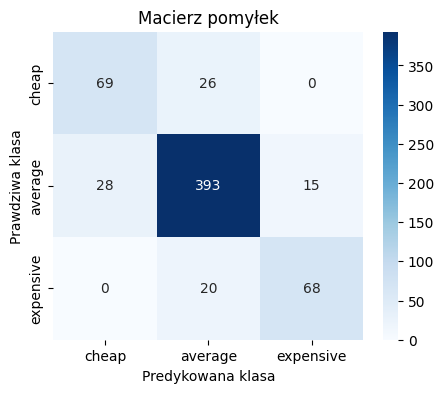

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(targets, preds)

plt.figure(figsize=(5, 4))
fig = sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels
)
plt.title("Macierz pomyłek")
plt.xlabel("Predykowana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()

In [92]:
class PriceRegressor(nn.Module):
    def __init__(self, in_features: int, hidden_units: int):
        super().__init__()

        self.stack = nn.Sequential(
            nn.Linear(in_features=in_features, out_features=hidden_units),
            nn.LeakyReLU(),
            nn.Dropout(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units // 2),
            nn.LeakyReLU(),
            nn.Dropout(),
            nn.Linear(in_features=hidden_units // 2, out_features=1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.stack(x)

In [93]:
from torchmetrics import MeanAbsoluteError


class LitPriceRegressor(L.LightningModule):
    def __init__(
        self,
        regressor: nn.Module,
    ):
        super().__init__()

        self.regressor = regressor

        self.criterion = nn.MSELoss()

        self.train_mae = MeanAbsoluteError()
        self.val_mae = MeanAbsoluteError()
        self.test_mae = MeanAbsoluteError()

    def training_step(self, batch, batch_idx):
        X, y = batch
        preds = self.regressor(X).view(-1)
        loss = self.criterion(preds, y)
        self.train_mae.update(preds, y)

        self.log("train/loss", loss, prog_bar=True)
        self.log(
            "train/mae", self.train_mae, on_step=True, on_epoch=True, prog_bar=True
        )
        return loss

    def validation_step(self, batch, batch_idx):
        X, y = batch
        preds = self.regressor(X).view(-1)
        loss = self.criterion(preds, y)
        self.val_mae.update(preds, y)

        self.log("val/loss", loss, prog_bar=True)
        self.log("val/mae", self.val_mae, on_step=False, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        X, y = batch
        preds = self.regressor(X).view(-1)
        self.test_mae.update(preds, y)

        self.log("test/mae", self.test_mae, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.regressor.parameters(), lr=1e-4)
        return optimizer

In [94]:
train_dataset = create_dataset(X_train, y_train["SalePrice"])
val_dataset = create_dataset(X_val, y_val["SalePrice"])

train_data_loader = torch.utils.data.DataLoader(train_dataset, batch_size)
val_data_loader = torch.utils.data.DataLoader(val_dataset, batch_size)

In [95]:
hidden_units = 256

regressor = PriceRegressor(in_features, hidden_units)
model = LitPriceRegressor(regressor)

In [96]:
trainer = L.Trainer(max_epochs=10, accelerator="cpu")
trainer.fit(model, train_dataloaders=train_data_loader, val_dataloaders=val_data_loader)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/daniel/Studia/Semestr_6/SSNE/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | regressor | PriceRegressor    | 39.7 K | train
1 | criterion | MSELoss           | 0      | train
2 | train_mae | MeanAbsoluteError | 0      | train
3 | val_mae   | MeanAbsoluteError | 0      | train
4 | test_mae  | MeanAbsoluteError | 0      | train
--------------------------------------------------------
39.7 K    Trainable params
0         Non-trainable params
39.7 K    Total params
0.159     Total estimated model params size (MB)
13     

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/daniel/Studia/Semestr_6/SSNE/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/daniel/Studia/Semestr_6/SSNE/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


In [97]:
preds_l = []
targets_l = []

device = torch.device("cpu")

regressor.eval()

for X_batch, target in val_data_loader:
    X_batch, target = X_batch.to(device), target.to(device)

    with torch.inference_mode():
        pred = regressor(X_batch)
        preds_l.extend(pred.cpu().numpy())
        targets_l.extend(target.cpu().numpy())

preds = np.array(preds_l)
targets = np.array(targets_l)

print(f"{preds.shape=}")
print(f"{targets.shape=}")

preds.shape=(619, 1)
targets.shape=(619,)


In [98]:
def price_to_class(price):
    if price <= 100000:
        return 0
    elif price <= 350000:
        return 1
    else:
        return 2


scaled_preds = np.squeeze(sale_price_scaler.inverse_transform(preds))
scaled_targets = np.squeeze(sale_price_scaler.inverse_transform(targets.reshape(-1, 1)))

pred_classes = np.array([price_to_class(pred) for pred in scaled_preds])
target_classes = np.array([price_to_class(target) for target in scaled_targets])

In [99]:
report = classification_report(target_classes, pred_classes, target_names=labels)
print(report)

              precision    recall  f1-score   support

       cheap       0.82      0.43      0.57        95
     average       0.84      0.95      0.89       436
   expensive       0.82      0.72      0.76        88

    accuracy                           0.84       619
   macro avg       0.83      0.70      0.74       619
weighted avg       0.83      0.84      0.82       619



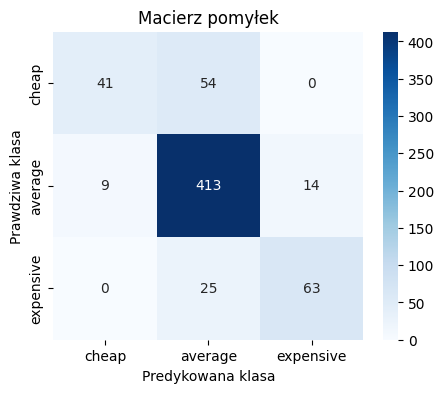

In [100]:
cm = confusion_matrix(target_classes, pred_classes)

plt.figure(figsize=(5, 4))
fig = sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels
)
plt.title("Macierz pomyłek")
plt.xlabel("Predykowana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()